# Exploration et Nettoyage de Données Sell4All

Ce notebook contient l'exploration initiale et le nettoyage des données clients pour le projet d'intelligence artificielle de Sell4All.

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

## 1 Lecture des Données et Aperçu

Nous commençons par charger le fichier de données `dataset-sell4all.csv` et afficher ses 5 premières lignes.

In [30]:
df = pd.read_csv('dataset-sell4all.csv')

#affichage des 5 premières lignes
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 2. Résumé Technique des Données

Pour obtenir un résumé technique complet de notre jeu de données (nombre de lignes, colonnes, types de données, valeurs manquantes), nous utilisons la méthode `info()` de Pandas.

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Name                     505 non-null    str  
 1   Phone Number             505 non-null    str  
 2   Email                    505 non-null    str  
 3   Address                  505 non-null    str  
 4   Country                  505 non-null    str  
 5   Postal code              505 non-null    str  
 6   Last date of connection  505 non-null    str  
 7   Last time of connection  505 non-null    str  
 8   Age                      505 non-null    int64
 9   Gender                   505 non-null    str  
 10  Customer spendings       505 non-null    int64
dtypes: int64(2), str(9)
memory usage: 43.5 KB


### Explication du Résumé Technique

1. **Combien y a-t-il d'entrées (lignes)?**
   * Le jeu de données contient **505 entrées** (lignes), indexées de `0` à `504`

2. **Qu'est-ce que « non-nul » ?**
   * Une valeur **non-nulle** signifie que la cellule correspondante contient une donnée valide et n'est pas vide 
   * Ici, toutes nos colonnes affichent `505 non-null`, ce qui indique qu'**il n'y a aucune valeur manquante** dans le jeu de données

3. **Quels types de données sont présents dans le jeu de données et que signifient-ils ?**
   * Deux types de données principaux sont détectés par Pandas :
     * **`int64` (Entiers de 64 bits)** : Concerne les valeurs numériques sans décimales
     Présent dans 2 colonnes :
       * `Age` : L'âge des clients
       * `Customer spendings` : Les dépenses des clients en euros
     * **`str` (Texte / Chaînes de caractères)** : représente des données textuelles
     Présent dans 9 colonnes :
       * `Name`, `Phone Number`, `Email`, `Address`, `Country`, `Last date of connection`, `Last time of connection`, `Gender`
       * `Postal code` est également détecté comme `str` car de nombreux pays utilisent des codes postaux contenant des lettres 

## 3. Calculs Statistiques

Dans cette section, nous calculons la moyenne et la médiane pour les colonnes `Age` et `Customer spendings`, ainsi que l'âge médian par pays

In [ ]:
# calculs pour l'âge
age_mean = df['Age'].mean()
age_median = df['Age'].median()

print(f"Âge - Moyenne : {age_mean:.2f} ans")
print(f"Âge - Médiane : {age_median:.1f} ans")

Âge - Moyenne : 46.08 ans
Âge - Médiane : 46.0 ans


In [ ]:
# calculs pour les dépenses des clients
spendings_mean = df['Customer spendings'].mean()
spendings_median = df['Customer spendings'].median()

print(f"Dépenses - Moyenne : {spendings_mean:.2f} €")
print(f"Dépenses - Médiane : {spendings_median:.1f} €")

Dépenses - Moyenne : 311.17 €
Dépenses - Médiane : 307.0 €


In [ ]:
# calcul de l'âge médian par pays
median_age_by_country = df.groupby('Country')['Age'].median()
median_age_by_country

Country
Australia             44.0
Austria               43.0
Belgium               39.0
Brazil                49.5
Canada                46.0
Chile                 46.0
China                 35.0
Colombia              29.0
Costa Rica            48.0
France                56.5
Germany               53.0
India                 45.5
Indonesia             41.5
Ireland               49.0
Italy                 41.0
Mexico                47.0
Netherlands           48.0
New Zealand           38.0
Nigeria               37.0
Norway                54.0
Pakistan              44.0
Peru                  38.0
Philippines           51.0
Poland                49.5
Russian Federation    48.0
Singapore             41.5
South Africa          43.0
South Korea           49.5
Spain                 54.5
Sweden                40.0
Turkey                60.0
Ukraine               46.0
United Kingdom        48.5
United States         48.5
Vietnam               48.0
Name: Age, dtype: float64

## 4. Visualisation des Données (Graphique à barres)

Pour analyser la répartition géographique des ventes de Sell4All, nous créons un graphique à barres représentant le montant total dépensé par les clients dans chaque pays

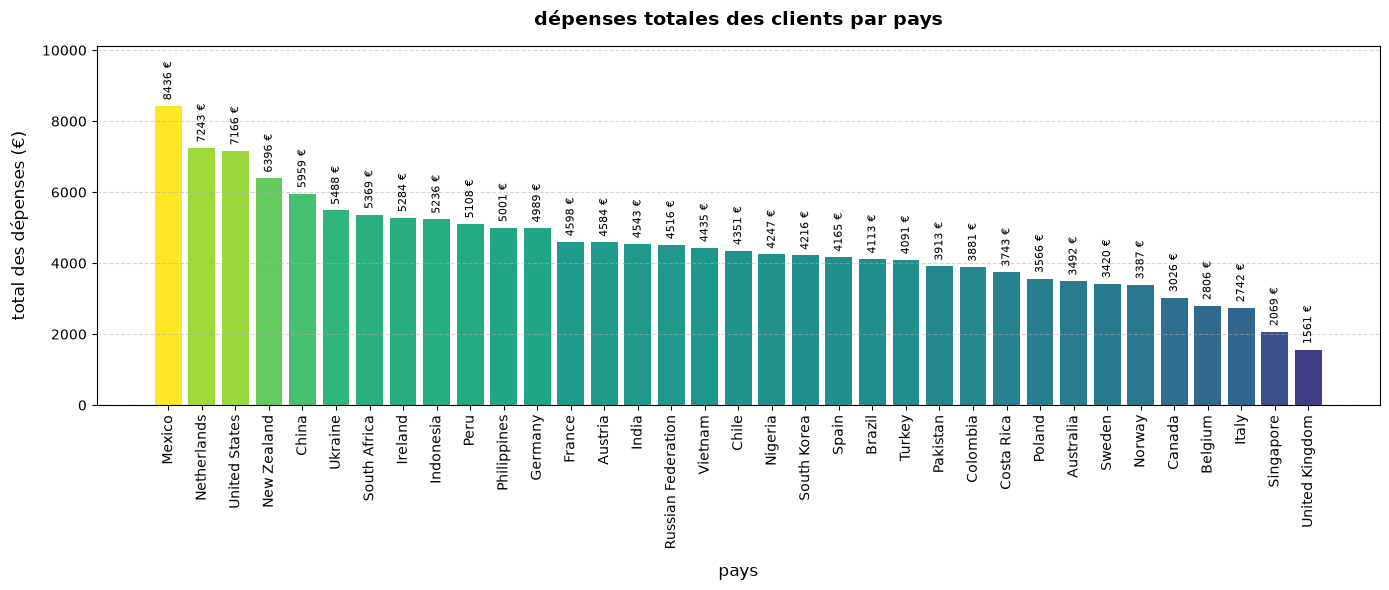

In [ ]:
spendings_by_country = df.groupby('Country')['Customer spendings'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))

colors = plt.cm.viridis(spendings_by_country.values / max(spendings_by_country.values))

bars = plt.bar(spendings_by_country.index, spendings_by_country.values, color=colors, edgecolor='none')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height} €',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=8, rotation=90)
plt.margins(y=0.2) # adds a 20% vertical margin so the text doesn't get cut off
plt.title('dépenses totales des clients par pays', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('pays', fontsize=12, labelpad=10)
plt.ylabel('total des dépenses (€)', fontsize=12, labelpad=10)
plt.xticks(rotation=90) # rotate the countries to prevent overlap
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

## 5. Nettoyage des Données

### 5.1  Suppression des clients ayant dépensé moins de 10 €

Les clients ayant des dépenses très faibles (moins de 10 €) peuvent représenter des transactions échouées, des comptes de test ou du bruit dans nos données. Nous les filtrons pour ne garder que les clients actifs

In [36]:
print(f"Nombre de clients avant filtrage : {len(df)}")
df = df[df['Customer spendings'] >= 10]
print(f"Nombre de clients après filtrage : {len(df)}")

Nombre de clients avant filtrage : 505
Nombre de clients après filtrage : 502


### 5.2  Suppression des doublons

Les doublons peuvent fausser nos analyses statistiques et surreprésenter certains comportements d'achat

In [37]:
print(f"Nombre de clients avant suppression des doublons : {len(df)}")
df = df.drop_duplicates()
print(f"Nombre de clients après suppression des doublons : {len(df)}")

Nombre de clients avant suppression des doublons : 502
Nombre de clients après suppression des doublons : 497


## 6. Export du jeu de données nettoyé

Après le nettoyage des données, nous créons un nouveau jeu de données contenant uniquement les colonnes demandées pour le projet :

- `Country`
- `Age`
- `Gender`
- `Customer spendings`

Ce jeu de données est ensuite exporté dans un nouveau fichier CSV nommé **`dataset-sell4all-cleaned.csv`**, prêt à être utilisé pour les prochaines étapes du projet

In [42]:
wanted_columns = ['Country', 'Age', 'Gender', 'Customer spendings']
df_cleaned = df[wanted_columns]
df_cleaned.to_csv('dataset-sell4all-cleaned.csv', index=False)
df_cleaned.head()

,Country,Age,Gender,Customer spendings
0,Norway,71,Man,356
1,Pakistan,37,Women,173
2,Colombia,24,Women,105
3,South Africa,37,Women,28
4,France,42,Women,13
